In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.datasets import mnist
from tensorflow.keras import backend as K

# 1. Define the Custom Math (REQUIRED to load the brain)
def euclidean_distance(vects):
    x, y = vects
    sum_square = K.sum(K.square(x - y), axis=1, keepdims=True)
    return K.sqrt(K.maximum(sum_square, K.epsilon()))

def contrastive_loss(y_true, y_pred):
    margin = 1.0
    square_pred = K.square(y_pred)
    margin_square = K.square(K.maximum(margin - y_pred, 0))
    return K.mean((1 - y_true) * square_pred + (y_true) * margin_square)

# 2. Load the Model
print("Loading model...")
try:
    model = load_model(
        'my_siamese_model.h5',
        custom_objects={
            'contrastive_loss': contrastive_loss,
            'euclidean_distance': euclidean_distance
        }
    )
    print("✅ Model loaded successfully!")
except Exception as e:
    print(f"❌ Error loading model: {e}")
    print("Make sure 'my_siamese_model.h5' is uploaded to the files section.")

# 3. Load and Prep Data (Required for x_test_flat)
print("Loading data...")
(_, _), (x_test, y_test) = mnist.load_data()
x_test_flat = x_test.astype('float32') / 255.0
x_test_flat = x_test_flat.reshape((-1, 784))
print("✅ Data ready.")

Loading model...
✅ Model loaded successfully!
Loading data...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
✅ Data ready.


In [ ]:
import numpy as np
import random

def evaluate_one_shot_accuracy(model, x_test_flat, y_test, trials=500, n_way=10):
    """
    Tests the One-Shot Learning performance.

    Parameters:
    - trials: How many times to test (higher = more accurate % score)
    - n_way: How many support classes to show (10 for MNIST)
    """
    n_correct = 0

    print(f"Running {trials} One-Shot Learning trials...")

    # Pre-calculate indices for each digit for faster access
    digit_indices = [np.where(y_test == i)[0] for i in range(10)]

    for i in range(trials):
        # 1. SELECT THE TRUE CLASS AND QUERY IMAGE
        true_class = random.randint(0, 9)
        query_idx = random.choice(digit_indices[true_class])
        query_img = x_test_flat[query_idx]

        # 2. BUILD THE SUPPORT SET (1 example per class)
        support_set = []
        for digit in range(10):
            # Pick a random image for this digit
            # (Important: If it's the true class, ensure we don't pick the EXACT same image as query)
            indices = digit_indices[digit]
            if digit == true_class:
                # Filter out the query image index to avoid cheating
                indices = indices[indices != query_idx]

            ref_idx = random.choice(indices)
            support_set.append(x_test_flat[ref_idx])

        support_set = np.array(support_set)

        # 3. RUN PREDICTION
        # Duplicate query to match support set size
        query_duplicated = np.array([query_img] * n_way)

        # Get distances
        distances = model.predict([query_duplicated, support_set], verbose=0)

        # 4. CHECK RESULT
        # The class with the minimum distance is the model's guess
        predicted_class = np.argmin(distances)

        if predicted_class == true_class:
            n_correct += 1

        # Optional: Print progress every 100 trials
        if (i+1) % 100 == 0:
            print(f"Completed {i+1} trials...")

    # 5. CALCULATE FINAL ACCURACY
    accuracy = (100.0 * n_correct / trials)
    print(f"------------------------------------------------")
    print(f"✅ One-Shot Accuracy: {accuracy:.2f}%")
    print(f"------------------------------------------------")
    return accuracy

# --- RUN THE EVALUATION ---
# Assuming 'x_test_flat' and 'y_test' are loaded from the previous step
final_score = evaluate_one_shot_accuracy(model, x_test_flat, y_test, trials=200)

Running 200 One-Shot Learning trials...
Completed 100 trials...
Completed 200 trials...
------------------------------------------------
✅ One-Shot Accuracy: 93.00%
------------------------------------------------


Upload your digit image...


Saving Screenshot 2026-01-29 154210.png to Screenshot 2026-01-29 154210.png

Analyzing 'Screenshot 2026-01-29 154210.png' against 5 references per class...
------------------------------
| Class | Avg Distance (Lower is better) |
------------------------------
|   0   | 0.8790  <--- BEST MATCH
|   1   | 0.8705  <--- BEST MATCH
|   2   | 0.0889  <--- BEST MATCH
|   3   | 0.8729 
|   4   | 1.2378 
|   5   | 0.9848 
|   6   | 0.8706 
|   7   | 0.8276 
|   8   | 0.9174 
|   9   | 1.2129 


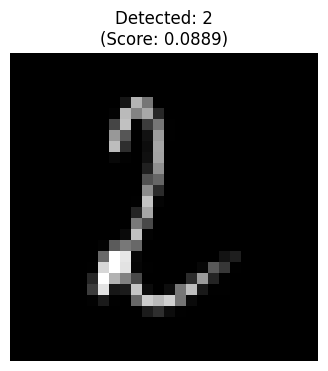


❌ RESULT: Model thinks it is a 2.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from google.colab import files
from tensorflow.keras.preprocessing import image

# --- 1. SMART PREPROCESSING (Fixes the "Corner" Problem) ---
def smart_process_image(filename):
    # Load image in grayscale
    img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

    # Invert colors if necessary (We need White Text on Black Background)
    # If the average pixel is bright (>127), it's likely a white page.
    if np.mean(img) > 127:
        img = cv2.bitwise_not(img)

    # Find the bounding box of the digit (trim empty borders)
    coords = cv2.findNonZero(img)
    x, y, w, h = cv2.boundingRect(coords)
    digit = img[y:y+h, x:x+w]

    # Resize to fit inside a 20x20 box (keeping aspect ratio)
    if w > h:
        scale = 20.0 / w
        new_w, new_h = 20, int(h * scale)
    else:
        scale = 20.0 / h
        new_w, new_h = int(w * scale), 20

    resized = cv2.resize(digit, (new_w, new_h), interpolation=cv2.INTER_AREA)

    # Paste centered onto a 28x28 black canvas
    final_img = np.zeros((28, 28), dtype=np.float32)
    start_x = (28 - new_w) // 2
    start_y = (28 - new_h) // 2
    final_img[start_y:start_y+new_h, start_x:start_x+new_w] = resized

    # Normalize 0-1
    return final_img / 255.0

# --- 2. ROBUST TESTING (Fixes the "Luck" Problem) ---
def test_with_stability(model, x_test_flat, y_test):
    print("Upload your digit image...")
    uploaded = files.upload()

    for filename in uploaded.keys():
        # A. Process the user image
        user_img = smart_process_image(filename)
        user_img_flat = user_img.reshape(1, 784)

        # B. Compare against 5 examples per class (Voting)
        avg_distances = []
        n_samples = 5  # "5-Shot" Validation for stability

        print(f"\nAnalyzing '{filename}' against {n_samples} references per class...")
        print("-" * 30)
        print(f"| Class | Avg Distance (Lower is better) |")
        print("-" * 30)

        for i in range(10):
            # Get indices for all images of digit 'i'
            indices = np.where(y_test == i)[0]

            # Pick 'n_samples' random images
            selection = np.random.choice(indices, n_samples, replace=False)
            support_imgs = x_test_flat[selection]

            # Duplicate user image to match shape
            user_imgs_repeated = np.repeat(user_img_flat, n_samples, axis=0)

            # Predict distances
            dists = model.predict([user_imgs_repeated, support_imgs], verbose=0)

            # Take the AVERAGE distance
            avg_dist = np.mean(dists)
            avg_distances.append(avg_dist)

            # Print score
            indicator = " <--- BEST MATCH" if avg_dist == min(avg_distances) else ""
            print(f"|   {i}   | {avg_dist:.4f} {indicator}")

        # C. Result
        best_match = np.argmin(avg_distances)
        confidence = avg_distances[best_match]

        # D. Visualization
        plt.figure(figsize=(4, 4))
        plt.title(f"Detected: {best_match}\n(Score: {confidence:.4f})")
        plt.imshow(user_img, cmap='gray')
        plt.axis('off')
        plt.show()

        if best_match == 3:
            print("\n✅ SUCCESS: The model correctly identified the 3.")
        else:
            print(f"\n❌ RESULT: Model thinks it is a {best_match}.")

# RUN IT
try:
    test_with_stability(model, x_test_flat, y_test)
except NameError:
    print("Error: Make sure you ran the 'Setup' cells to load the model and data first!")

STEP 1: Upload your QUERY image (The one to classify)


Saving Screenshot 2026-01-29 154144.png to Screenshot 2026-01-29 154144.png

STEP 2: Upload your SUPPORT images (The reference dictionary)
⚠️ NOTE: Name files like '3_ref.png' or '0.jpg' so code knows the label.


Saving eight.png to eight (1).png
Saving six.png to six (1).png
Saving two.png to two (1).png

------------------------------------------------------------
| Image Name           | Label | Similarity Score |
------------------------------------------------------------
| eight (1).png        | ?     | 0.9020 
| six (1).png          | ?     | 0.6530 
| two (1).png          | ?     | 0.6392 <--- BEST MATCH
------------------------------------------------------------


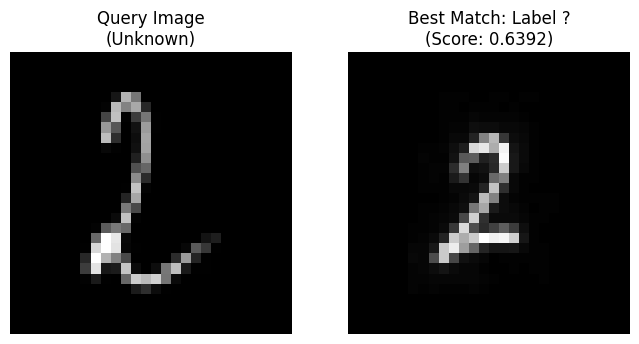


✅ Final Classification: The image is a ?


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from google.colab import files

# --- 1. SMART PREPROCESSING (Keeps everything consistent) ---
def smart_process_image(filename):
    # Load grayscale
    img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

    # Invert if background is white (We want black background)
    if np.mean(img) > 127:
        img = cv2.bitwise_not(img)

    # Crop to the digit
    coords = cv2.findNonZero(img)
    x, y, w, h = cv2.boundingRect(coords)
    digit = img[y:y+h, x:x+w]

    # Resize to max 20x20
    if w > h:
        scale = 20.0 / w
        new_w, new_h = 20, int(h * scale)
    else:
        scale = 20.0 / h
        new_w, new_h = int(w * scale), 20

    resized = cv2.resize(digit, (new_w, new_h), interpolation=cv2.INTER_AREA)

    # Center on 28x28 canvas
    final_img = np.zeros((28, 28), dtype=np.float32)
    start_x = (28 - new_w) // 2
    start_y = (28 - new_h) // 2
    final_img[start_y:start_y+new_h, start_x:start_x+new_w] = resized

    return final_img / 255.0

# --- 2. THE USER-DEFINED ONE-SHOT TASK ---
def manual_one_shot_test(model):
    print("STEP 1: Upload your QUERY image (The one to classify)")
    query_upload = files.upload()
    query_filename = list(query_upload.keys())[0]

    # Process Query
    query_img = smart_process_image(query_filename)
    query_img_flat = query_img.reshape(1, 784)

    print("\nSTEP 2: Upload your SUPPORT images (The reference dictionary)")
    print("⚠️ NOTE: Name files like '3_ref.png' or '0.jpg' so code knows the label.")
    support_upload = files.upload()

    support_imgs = []
    support_labels = []
    support_filenames = []

    # Process Support Set
    for filename in support_upload.keys():
        # Heuristic: First character of filename is the label
        try:
            label = int(filename[0])
        except ValueError:
            label = "?" # Fallback if filename is weird

        img = smart_process_image(filename)
        support_imgs.append(img.reshape(784))
        support_labels.append(label)
        support_filenames.append(filename)

    support_imgs = np.array(support_imgs)

    # --- PREDICTION ---
    # Repeat query to match number of support images
    n_support = len(support_imgs)
    query_repeated = np.repeat(query_img_flat, n_support, axis=0)

    distances = model.predict([query_repeated, support_imgs], verbose=0)

    # --- RESULTS TABLE ---
    print(f"\n{'-'*60}")
    print(f"| {'Image Name':<20} | {'Label':<5} | {'Similarity Score':<15} |")
    print(f"{'-'*60}")

    for i in range(n_support):
        score = distances[i][0]
        fname = support_filenames[i]
        lbl = support_labels[i]

        # Mark the winner visually in the table
        marker = ""
        if score == np.min(distances):
            marker = "<--- BEST MATCH"

        print(f"| {fname:<20} | {lbl:<5} | {score:.4f} {marker}")

    print(f"{'-'*60}")

    # --- VISUALIZE WINNER ---
    best_idx = np.argmin(distances)
    best_label = support_labels[best_idx]
    best_score = distances[best_idx][0]

    plt.figure(figsize=(8, 4))

    # Plot Query
    plt.subplot(1, 2, 1)
    plt.title(f"Query Image\n(Unknown)")
    plt.imshow(query_img, cmap='gray')
    plt.axis('off')

    # Plot Match
    plt.subplot(1, 2, 2)
    plt.title(f"Best Match: Label {best_label}\n(Score: {best_score:.4f})")
    plt.imshow(support_imgs[best_idx].reshape(28, 28), cmap='gray')
    plt.axis('off')

    plt.show()
    print(f"\n✅ Final Classification: The image is a {best_label}")

# RUN IT
try:
    manual_one_shot_test(model)
except NameError:
    print("Error: Please run the Setup cell to load 'model' first.")